In [4]:
# !pip install --upgrade seaborn
# !pip install --upgrade numpy

In [3]:
# we use pandas for data preprocessing and reading
import pandas as pd
import numpy as np
from surprise import Dataset, Reader, KNNBasic
from mlxtend.preprocessing import TransactionEncoder

# plot data
import matplotlib.pyplot as plt
import seaborn as sns

# we need split API from surprise to split the data set into train/test
from surprise.model_selection import train_test_split

# we need to Load libraries and use apriori
from mlxtend.frequent_patterns import apriori,association_rules

# we alos need scikit-learn metrics module for accuracy calculation
from sklearn import metrics                


In [5]:
# load in the Online retail data into dataframe
online_retail_df = pd.read_csv("Online_Retail.csv")

# first 5 rows
online_retail_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [7]:
# Clean data: remove rows with NaN descriptions or Quantity <= 0
online_retail_df = online_retail_df[(online_retail_df['Quantity'] > 0) & (online_retail_df['Description'].notnull())]

In [9]:
# Group by invoice No and description convert to a list
basket = online_retail_df.groupby("InvoiceNo")["Description"].apply(list)
basket.head()

InvoiceNo
536365    [WHITE HANGING HEART T-LIGHT HOLDER, WHITE MET...
536366    [HAND WARMER UNION JACK, HAND WARMER RED POLKA...
536367    [ASSORTED COLOUR BIRD ORNAMENT, POPPY'S PLAYHO...
536368    [JAM MAKING SET WITH JARS, RED COAT RACK PARIS...
536369                           [BATH BUILDING BLOCK WORD]
Name: Description, dtype: object

In [11]:
# One-hot encoding and view the first five records
te = TransactionEncoder()
te_ary = te.fit(basket).transform(basket)
basket_df = pd.DataFrame(te_ary, columns=te.columns_)
basket_df.head()

,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,returned,taig adjust,test,to push order througha s stock was,website fixed,wrongly coded 20713,wrongly coded 23343,wrongly marked,wrongly marked 23343,wrongly sold (22719) barcode
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [13]:
# Apply Apriori algorithm to find frequent itemsets
frequent_itemsets = apriori(basket_df,min_support=0.02,use_colnames=True)
frequent_itemsets

,support,itemsets
0,0.023242,(3 STRIPEY MICE FELTCRAFT)
1,0.024037,(4 TRADITIONAL SPINNING TOPS)
2,0.047427,(6 RIBBONS RUSTIC CHARM)
3,0.021702,(60 CAKE CASES DOLLY GIRL DESIGN)
4,0.030691,(60 CAKE CASES VINTAGE CHRISTMAS)
...,...,...
370,0.020262,"(WHITE HANGING HEART T-LIGHT HOLDER, WOODEN PI..."
371,0.026768,"(WOODEN FRAME ANTIQUE WHITE , WOODEN PICTURE F..."
372,0.026917,"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY..."
373,0.020262,"(GREEN REGENCY TEACUP AND SAUCER, REGENCY CAKE..."


In [15]:
# Sort by support and display the top 20 
frequent_itemsets_top_20 = frequent_itemsets.sort_values(by="support", ascending=False).head(20)

# Reset index of that top 20 subset
frequent_itemsets_top_20 = frequent_itemsets_top_20.reset_index(drop=True)

# Display result
frequent_itemsets_top_20

,support,itemsets
0,0.112237,(WHITE HANGING HEART T-LIGHT HOLDER)
1,0.103894,(JUMBO BAG RED RETROSPOT)
2,0.098778,(REGENCY CAKESTAND 3 TIER)
3,0.083731,(PARTY BUNTING)
4,0.077672,(LUNCH BAG RED RETROSPOT)
5,0.072259,(ASSORTED COLOUR BIRD ORNAMENT)
6,0.068782,(SET OF 3 CAKE TINS PANTRY DESIGN )
7,0.065554,(PACK OF 72 RETROSPOT CAKE CASES)
8,0.063220,(LUNCH BAG BLACK SKULL.)
9,0.062028,(NATURAL SLATE HEART CHALKBOARD )


In [17]:
# Filter itemsets that are exactly size 2
top_pairs = frequent_itemsets[frequent_itemsets['itemsets'].apply(lambda x: len(x) == 2)]

# Sort by support
top_pairs = top_pairs.sort_values(by="support", ascending=False)

# Get top 20 pairs
top_pairs_top_20 = top_pairs.head(20).reset_index(drop=True)

# Display result
top_pairs_top_20

,support,itemsets
0,0.040971,"(JUMBO BAG PINK POLKADOT, JUMBO BAG RED RETROS..."
1,0.038141,"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC..."
2,0.035956,"(JUMBO BAG RED RETROSPOT, JUMBO STORAGE BAG SUKI)"
3,0.033770,"(JUMBO BAG RED RETROSPOT, JUMBO SHOPPER VINTAG..."
4,0.031834,"(LUNCH BAG RED RETROSPOT, LUNCH BAG BLACK SKU..."
5,0.031784,"(ALARM CLOCK BAKELIKE GREEN, ALARM CLOCK BAKEL..."
6,0.031436,"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY..."
7,0.030095,"(LUNCH BAG RED RETROSPOT, LUNCH BAG PINK POLKA..."
8,0.029748,"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY..."
9,0.029052,"(JUMBO BAG RED RETROSPOT, JUMBO BAG BAROQUE B..."


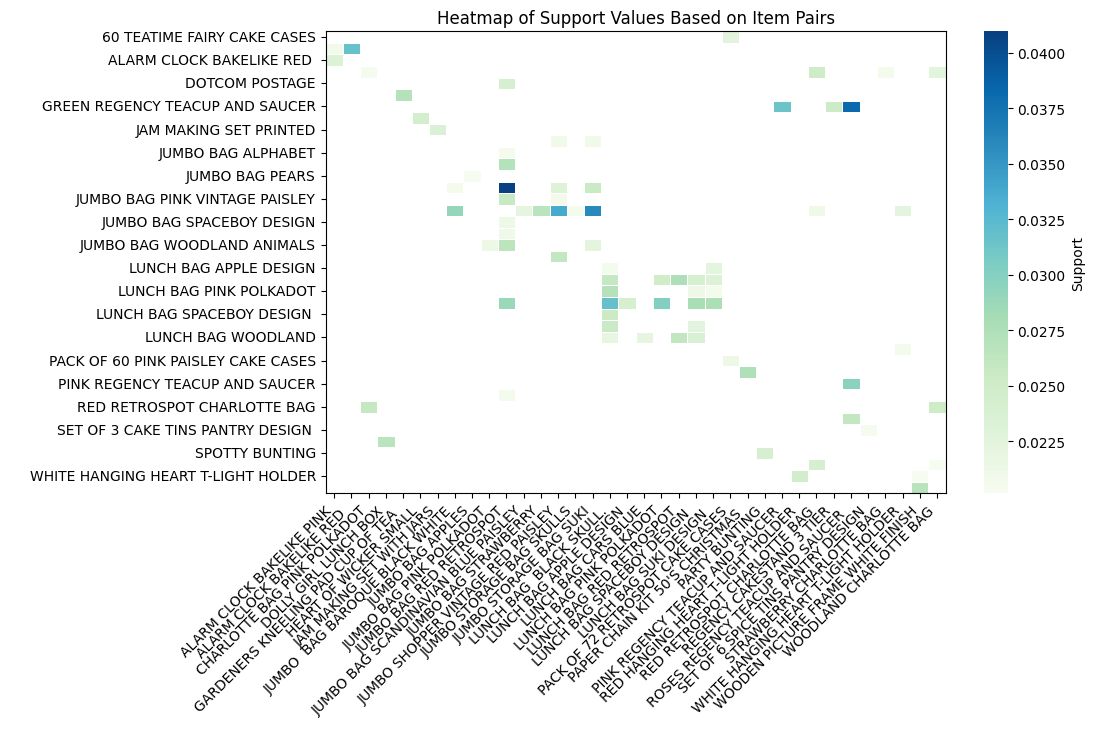

In [19]:
# Avoid Setting With Copy Warning by copying the DataFrame
top_pairs = top_pairs.copy()

# Extract items from frozensets
top_pairs['Item 1'] = top_pairs['itemsets'].apply(lambda x: list(x)[0])
top_pairs['Item 2'] = top_pairs['itemsets'].apply(lambda x: list(x)[1])

# Create pivot table for heatmap
heatmap_data = pd.crosstab(top_pairs['Item 1'], top_pairs['Item 2'], values=top_pairs['support'], aggfunc='mean',dropna=True)

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, cmap="GnBu", annot=False, fmt=".1f",cbar_kws={'label':'Support'}, linewidths=0.5)
plt.title("Heatmap of Support Values Based on Item Pairs")
plt.xticks(rotation = 45, ha ="right")
plt.gca().spines['top'].set_visible(True)
plt.gca().spines['right'].set_visible(True)
plt.gca().spines['left'].set_visible(True)
plt.gca().spines['bottom'].set_visible(True)
plt.xlabel(' ')
plt.ylabel(' ')
plt.show()

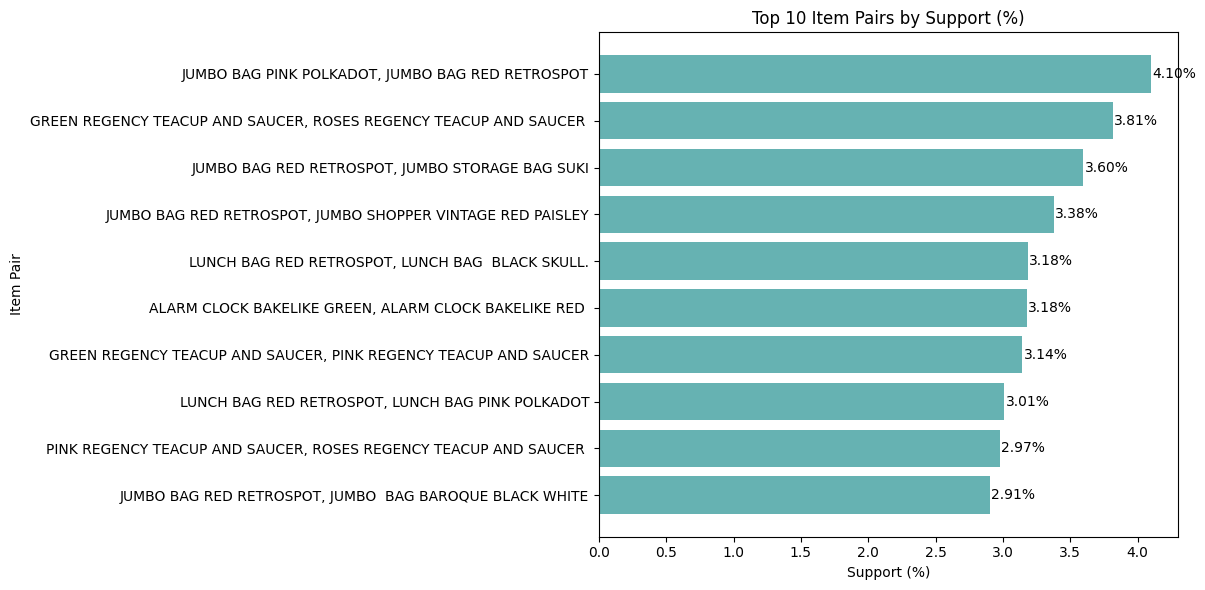

In [21]:
# Select top 10 item pairs
top_pairs = frequent_itemsets[frequent_itemsets['itemsets'].apply(lambda x: len(x) == 2)].sort_values(by="support", ascending=False).head(10).copy()

# Convert frozensets to comma-separated strings for labels
top_pairs['items'] = top_pairs['itemsets'].apply(lambda x: ', '.join(list(x)))
support_values = top_pairs['support'] * 100

# Plot horizontal bar chart
plt.figure(figsize=(12, 6))
bars = plt.barh(top_pairs['items'], support_values, color='#66b2b2')

# Add support % labels next to bars
for bar in bars:
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.2f}%', va='center', ha='left', color='black', fontsize=10)

plt.title("Top 10 Item Pairs by Support (%)")
plt.xlabel("Support (%)")
plt.ylabel("Item Pair")
plt.gca().invert_yaxis()  # Show highest at top
plt.tight_layout()
plt.show()

In [23]:
# Generate association rules using 'lift' as metric
initial_rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# Select relevant columns and sort by lift descending
rules = initial_rules[['antecedents','consequents','antecedent support','consequent support','support','confidence','lift']].sort_values(by = "lift", ascending=False)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
159,"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",(PINK REGENCY TEACUP AND SAUCER),0.038141,0.038041,0.026917,0.705729,18.551648
162,(PINK REGENCY TEACUP AND SAUCER),"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",0.038041,0.038141,0.026917,0.707572,18.551648
160,"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",(GREEN REGENCY TEACUP AND SAUCER),0.029748,0.050407,0.026917,0.904841,17.950627
161,(GREEN REGENCY TEACUP AND SAUCER),"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",0.050407,0.029748,0.026917,0.533990,17.950627
25,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.038041,0.050407,0.031436,0.826371,16.393893
...,...,...,...,...,...,...,...
155,(WOODEN PICTURE FRAME WHITE FINISH),(WHITE HANGING HEART T-LIGHT HOLDER),0.054629,0.112237,0.020262,0.370909,3.304702
132,(NATURAL SLATE HEART CHALKBOARD ),(WHITE HANGING HEART T-LIGHT HOLDER),0.062028,0.112237,0.020610,0.332266,2.960400
133,(WHITE HANGING HEART T-LIGHT HOLDER),(NATURAL SLATE HEART CHALKBOARD ),0.112237,0.062028,0.020610,0.183628,2.960400
82,(JUMBO BAG RED RETROSPOT),(WHITE HANGING HEART T-LIGHT HOLDER),0.103894,0.112237,0.022298,0.214627,1.912271


In [41]:
# Create a readable rule string like "A, B --> C"
rules['rule']  = rules['antecedents'].apply(lambda x: ','.join(sorted(x))) + "-->" + rules['consequents'].apply(lambda x: ','.join(sorted(x)))
rules = rules[['rule'] + [ col for col in rules.columns if col != 'rule']]
rules = rules.reset_index(drop=True)
rules

,rule,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
0,"GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY ...","(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",(PINK REGENCY TEACUP AND SAUCER),0.038141,0.038041,0.026917,0.705729,18.551648
1,PINK REGENCY TEACUP AND SAUCER-->GREEN REGENCY...,(PINK REGENCY TEACUP AND SAUCER),"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",0.038041,0.038141,0.026917,0.707572,18.551648
2,"PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY T...","(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",(GREEN REGENCY TEACUP AND SAUCER),0.029748,0.050407,0.026917,0.904841,17.950627
3,GREEN REGENCY TEACUP AND SAUCER-->PINK REGENCY...,(GREEN REGENCY TEACUP AND SAUCER),"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",0.050407,0.029748,0.026917,0.533990,17.950627
4,PINK REGENCY TEACUP AND SAUCER-->GREEN REGENCY...,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.038041,0.050407,0.031436,0.826371,16.393893
...,...,...,...,...,...,...,...,...
171,WOODEN PICTURE FRAME WHITE FINISH-->WHITE HANG...,(WOODEN PICTURE FRAME WHITE FINISH),(WHITE HANGING HEART T-LIGHT HOLDER),0.054629,0.112237,0.020262,0.370909,3.304702
172,NATURAL SLATE HEART CHALKBOARD -->WHITE HANGIN...,(NATURAL SLATE HEART CHALKBOARD ),(WHITE HANGING HEART T-LIGHT HOLDER),0.062028,0.112237,0.020610,0.332266,2.960400
173,WHITE HANGING HEART T-LIGHT HOLDER-->NATURAL S...,(WHITE HANGING HEART T-LIGHT HOLDER),(NATURAL SLATE HEART CHALKBOARD ),0.112237,0.062028,0.020610,0.183628,2.960400
174,JUMBO BAG RED RETROSPOT-->WHITE HANGING HEART ...,(JUMBO BAG RED RETROSPOT),(WHITE HANGING HEART T-LIGHT HOLDER),0.103894,0.112237,0.022298,0.214627,1.912271


In [45]:
# Filter rules for high lift and high confidence
strong_rules = rules[(rules['lift'] > 10) & (rules['confidence'] > 0.5)]

# Display results
strong_rules

,rule,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
0,"GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY ...","(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",(PINK REGENCY TEACUP AND SAUCER),0.038141,0.038041,0.026917,0.705729,18.551648
1,PINK REGENCY TEACUP AND SAUCER-->GREEN REGENCY...,(PINK REGENCY TEACUP AND SAUCER),"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",0.038041,0.038141,0.026917,0.707572,18.551648
2,"PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY T...","(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",(GREEN REGENCY TEACUP AND SAUCER),0.029748,0.050407,0.026917,0.904841,17.950627
3,GREEN REGENCY TEACUP AND SAUCER-->PINK REGENCY...,(GREEN REGENCY TEACUP AND SAUCER),"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",0.050407,0.029748,0.026917,0.533990,17.950627
4,PINK REGENCY TEACUP AND SAUCER-->GREEN REGENCY...,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.038041,0.050407,0.031436,0.826371,16.393893
5,GREEN REGENCY TEACUP AND SAUCER-->PINK REGENCY...,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.050407,0.038041,0.031436,0.623645,16.393893
6,"GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY T...","(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...",(ROSES REGENCY TEACUP AND SAUCER ),0.031436,0.052940,0.026917,0.856240,16.173782
7,ROSES REGENCY TEACUP AND SAUCER -->GREEN REGEN...,(ROSES REGENCY TEACUP AND SAUCER ),"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...",0.052940,0.031436,0.026917,0.508443,16.173782
8,GARDENERS KNEELING PAD KEEP CALM -->GARDENERS ...,(GARDENERS KNEELING PAD KEEP CALM ),(GARDENERS KNEELING PAD CUP OF TEA ),0.045342,0.037644,0.027116,0.598028,15.886413
9,GARDENERS KNEELING PAD CUP OF TEA -->GARDENERS...,(GARDENERS KNEELING PAD CUP OF TEA ),(GARDENERS KNEELING PAD KEEP CALM ),0.037644,0.045342,0.027116,0.720317,15.886413


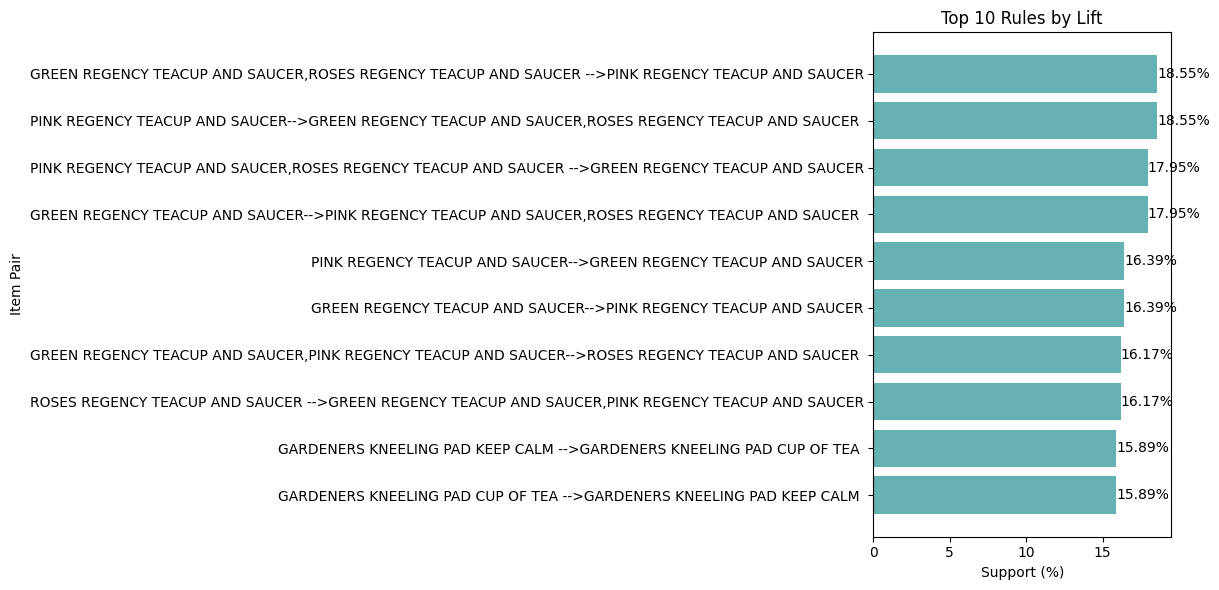

In [47]:
# Select top 10 rules

rule = rules['rule'].head(10)
lift_values = rules['lift'].head(10)

# Plot horizontal bar chart
plt.figure(figsize=(12, 6))
bars = plt.barh(rule, lift_values, color='#66b2b2')

# Add support % labels next to bars
for bar in bars:
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.2f}%', va='center', ha='left', color='black', fontsize=10)

plt.title("Top 10 Rules by Lift")
plt.xlabel("Support (%)")
plt.ylabel("Item Pair")
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()

In [ ]:
# end 